In [2]:
import sys
import os

src_path = os.path.abspath(os.path.join('..', 'src'))
if src_path not in sys.path:
    sys.path.append(src_path)

In [3]:
from models import BaselineCNN, DeepCNN, count_parameters

model = BaselineCNN(num_classes=7)
print(f"Parametri: {count_parameters(model):,}")

Parametri: 683,527


### Qui lanciamo La BaselineCNN

In [4]:
import sys
sys.path.append('..')

from src.data import build_and_save_arrays, get_dataloaders, load_arrays
from src.models import BaselineCNN
from src.train import train_model

# 1. costruisci gli array (solo se non già salvati) e ricaricali
label2idx = build_and_save_arrays(
    '../dataset/processed/train_final_index.csv',
    '../dataset/processed/val_index.csv',
    '../dataset/processed/test_index_clean.csv',
    '../dataset/processed/fer_arrays.npz'
)
data = load_arrays('../dataset/processed/fer_arrays.npz')

# 2. dataloader
train_loader, val_loader, test_loader = get_dataloaders(
    '../dataset/processed/fer_arrays.npz', label2idx
)

# 3. modello + training
model = BaselineCNN(num_classes=7)
model, history = train_model(
    model, train_loader, val_loader,
    num_classes=7,
    y_train=data['y_train'],
    use_class_weights=True,
    epochs=50,
    patience=7,
    checkpoint_path='../results/baseline_cnn.pt'
)

/home/stetux/projects/NAML/FacialExpressionRecognition/notebooks/../src/train.py:115: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler() if device.type == 'cuda' else None


Epoch   1/50 | train_loss=1.7936 train_acc=0.2957 | val_loss=1.6215 val_acc=0.3963 | lr=1.00e-03 | 15.9s
Epoch   2/50 | train_loss=1.6002 train_acc=0.4051 | val_loss=1.4811 val_acc=0.4672 | lr=1.00e-03 | 13.2s
Epoch   3/50 | train_loss=1.4916 train_acc=0.4504 | val_loss=1.3908 val_acc=0.4968 | lr=1.00e-03 | 12.9s
Epoch   4/50 | train_loss=1.4103 train_acc=0.4789 | val_loss=1.3106 val_acc=0.5191 | lr=1.00e-03 | 13.6s
Epoch   5/50 | train_loss=1.3609 train_acc=0.4973 | val_loss=1.2895 val_acc=0.5280 | lr=1.00e-03 | 13.1s
Epoch   6/50 | train_loss=1.3307 train_acc=0.5103 | val_loss=1.2900 val_acc=0.5302 | lr=1.00e-03 | 14.0s
Epoch   7/50 | train_loss=1.3050 train_acc=0.5179 | val_loss=1.2637 val_acc=0.5384 | lr=1.00e-03 | 13.7s
Epoch   8/50 | train_loss=1.2836 train_acc=0.5235 | val_loss=1.2495 val_acc=0.5458 | lr=1.00e-03 | 17.6s
Epoch   9/50 | train_loss=1.2681 train_acc=0.5321 | val_loss=1.2393 val_acc=0.5455 | lr=1.00e-03 | 12.9s
Epoch  10/50 | train_loss=1.2490 train_acc=0.5369 | val

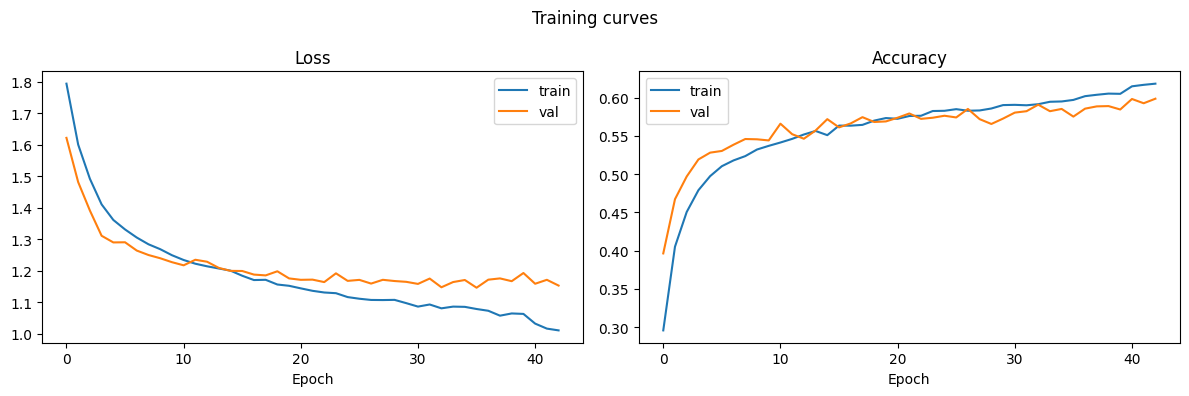

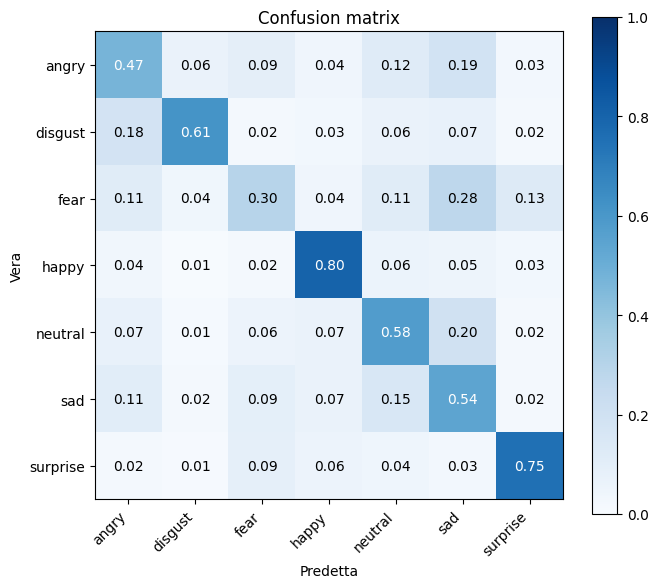

              precision    recall  f1-score   support

       angry      0.506     0.471     0.488       946
     disgust      0.291     0.615     0.395       109
        fear      0.439     0.295     0.353      1013
       happy      0.832     0.802     0.817      1767
     neutral      0.555     0.576     0.566      1225
         sad      0.453     0.540     0.493      1240
    surprise      0.707     0.754     0.730       792

    accuracy                          0.593      7092
   macro avg      0.541     0.579     0.549      7092
weighted avg      0.596     0.593     0.590      7092

Macro F1 (media semplice tra classi, penalizza le classi piccole se vanno male): 0.549
Weighted F1 (pesata per frequenza di classe): 0.590


In [7]:
from src.evaluate import evaluate_model

class_names = sorted(label2idx, key=label2idx.get)  # ordine coerente con gli indici usati nel training

y_true, y_pred = evaluate_model(model, test_loader, class_names, history=history)

In [2]:
#Ci assicuriamo di star usando la GPU

import torch
print(torch.cuda.is_available())      # deve dare True
print(torch.cuda.get_device_name(0))  # deve dare "NVIDIA GeForce GTX 1650 ..."

True
NVIDIA GeForce GTX 1650 with Max-Q Design


### Lanciamo la DeepCNN

In [8]:
import sys
sys.path.append('..')

from src.data import build_and_save_arrays, get_dataloaders, load_arrays
from src.models import DeepCNN
from src.train import train_model

# 1. costruisci gli array (solo se non già salvati) e ricaricali
label2idx = build_and_save_arrays(
    '../dataset/processed/train_final_index.csv',
    '../dataset/processed/val_index.csv',
    '../dataset/processed/test_index_clean.csv',
    '../dataset/processed/fer_arrays.npz'
)
data = load_arrays('../dataset/processed/fer_arrays.npz')

# 2. dataloader
train_loader, val_loader, test_loader = get_dataloaders(
    '../dataset/processed/fer_arrays.npz', label2idx
)

# 3. modello + training
model = DeepCNN(num_classes=7)
model, history = train_model(
    model, train_loader, val_loader,
    num_classes=7,
    y_train=data['y_train'],
    use_class_weights=True,
    epochs=50,
    patience=7,
    checkpoint_path='../results/deep_cnn.pt'
)

/home/stetux/projects/NAML/FacialExpressionRecognition/notebooks/../src/train.py:115: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler() if device.type == 'cuda' else None


Epoch   1/50 | train_loss=1.6762 train_acc=0.3644 | val_loss=1.4352 val_acc=0.4701 | lr=1.00e-03 | 115.7s
Epoch   2/50 | train_loss=1.4010 train_acc=0.4884 | val_loss=1.2932 val_acc=0.5328 | lr=1.00e-03 | 103.1s
Epoch   3/50 | train_loss=1.3071 train_acc=0.5201 | val_loss=1.3521 val_acc=0.5091 | lr=1.00e-03 | 103.4s
Epoch   4/50 | train_loss=1.2515 train_acc=0.5389 | val_loss=1.2289 val_acc=0.5380 | lr=1.00e-03 | 103.7s
Epoch   5/50 | train_loss=1.2046 train_acc=0.5583 | val_loss=1.2187 val_acc=0.5573 | lr=1.00e-03 | 103.7s
Epoch   6/50 | train_loss=1.1774 train_acc=0.5686 | val_loss=1.1463 val_acc=0.5892 | lr=1.00e-03 | 103.8s
Epoch   7/50 | train_loss=1.1510 train_acc=0.5764 | val_loss=1.1862 val_acc=0.5551 | lr=1.00e-03 | 103.4s
Epoch   8/50 | train_loss=1.1256 train_acc=0.5913 | val_loss=1.1337 val_acc=0.5900 | lr=1.00e-03 | 103.7s
Epoch   9/50 | train_loss=1.0982 train_acc=0.6013 | val_loss=1.1167 val_acc=0.5904 | lr=1.00e-03 | 103.1s
Epoch  10/50 | train_loss=1.0991 train_acc=0.5

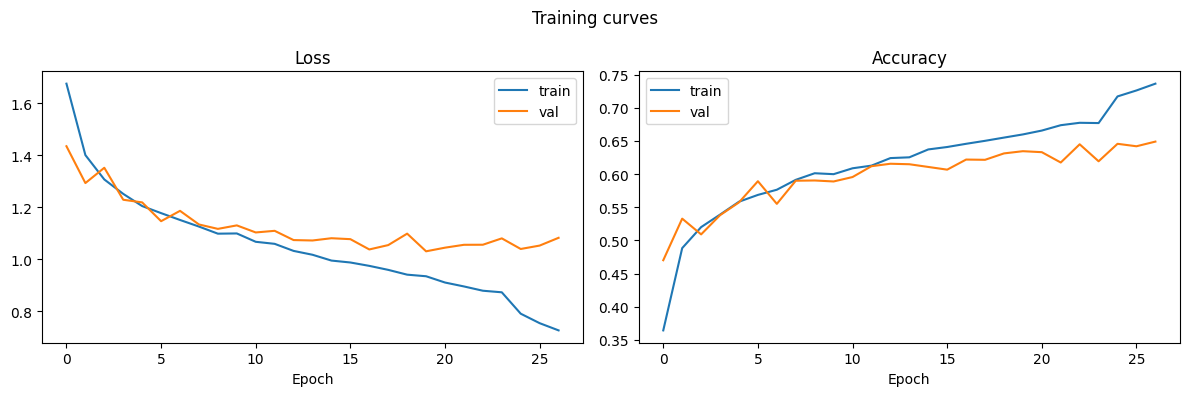

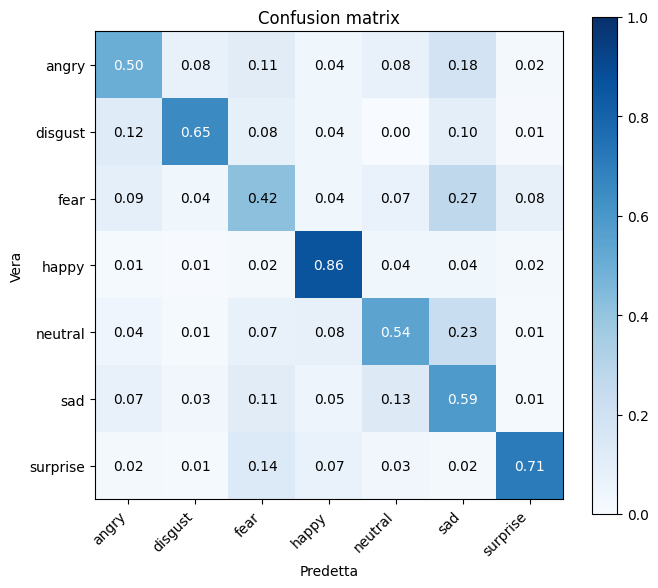

              precision    recall  f1-score   support

       angry      0.621     0.500     0.554       946
     disgust      0.275     0.651     0.387       109
        fear      0.465     0.417     0.439      1013
       happy      0.840     0.863     0.851      1767
     neutral      0.627     0.544     0.583      1225
         sad      0.468     0.589     0.522      1240
    surprise      0.774     0.710     0.740       792

    accuracy                          0.627      7092
   macro avg      0.581     0.611     0.582      7092
weighted avg      0.639     0.627     0.629      7092

Macro F1 (media semplice tra classi, penalizza le classi piccole se vanno male): 0.582
Weighted F1 (pesata per frequenza di classe): 0.629


In [9]:
from src.evaluate import evaluate_model

class_names = sorted(label2idx, key=label2idx.get)  # ordine coerente con gli indici usati nel training

y_true, y_pred = evaluate_model(model, test_loader, class_names, history=history)

In [10]:
train_loader, val_loader, test_loader = get_dataloaders(
    '../dataset/processed/fer_arrays.npz', label2idx, num_workers=4
)

#### Usiamo Focal Loss + classweights
Si è rivelato però con prestazioni peggiori della DeepCNN precedente. 

In [3]:
##Cambio approccio per disgust, qui uso focal loss

import sys
sys.path.append('..')

from src.data import build_and_save_arrays, get_dataloaders, load_arrays
from src.models import DeepCNN
from src.train import train_model

# 1. costruisci gli array (solo se non già salvati) e ricaricali
label2idx = build_and_save_arrays(
    '../dataset/processed/train_final_index.csv',
    '../dataset/processed/val_index.csv',
    '../dataset/processed/test_index_clean.csv',
    '../dataset/processed/fer_arrays.npz'
)
data = load_arrays('../dataset/processed/fer_arrays.npz')

# 2. dataloader
train_loader, val_loader, test_loader = get_dataloaders(
    '../dataset/processed/fer_arrays.npz', label2idx
)


model = DeepCNN(num_classes=7)
model, history = train_model(
    model, train_loader, val_loader,
    num_classes=7, y_train=data['y_train'],
    use_class_weights=True,
    loss_type='focal', focal_gamma=2.0,  
    epochs=50, patience=7,
    checkpoint_path='../results/deep_cnn_focal.pt'   
)

/home/stetux/projects/NAML/FacialExpressionRecognition/notebooks/../src/train.py:144: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler() if device.type == 'cuda' else None


Epoch   1/50 | train_loss=0.3087 train_acc=0.1450 | val_loss=0.2691 val_acc=0.1696 | lr=1.00e-03 | 109.1s
Epoch   2/50 | train_loss=0.2651 train_acc=0.1773 | val_loss=0.2662 val_acc=0.1814 | lr=1.00e-03 | 104.0s
Epoch   3/50 | train_loss=0.2382 train_acc=0.2413 | val_loss=0.2232 val_acc=0.2096 | lr=1.00e-03 | 104.0s
Epoch   4/50 | train_loss=0.2199 train_acc=0.2903 | val_loss=0.2208 val_acc=0.2709 | lr=1.00e-03 | 103.2s
Epoch   5/50 | train_loss=0.2069 train_acc=0.3172 | val_loss=0.1966 val_acc=0.3406 | lr=1.00e-03 | 102.8s
Epoch   6/50 | train_loss=0.2032 train_acc=0.3290 | val_loss=0.1921 val_acc=0.3310 | lr=1.00e-03 | 102.7s
Epoch   7/50 | train_loss=0.1981 train_acc=0.3508 | val_loss=0.1830 val_acc=0.3788 | lr=1.00e-03 | 102.7s
Epoch   8/50 | train_loss=0.2055 train_acc=0.3196 | val_loss=0.2101 val_acc=0.3518 | lr=1.00e-03 | 102.7s
Epoch   9/50 | train_loss=0.1895 train_acc=0.3504 | val_loss=0.2229 val_acc=0.2516 | lr=1.00e-03 | 102.7s
Epoch  10/50 | train_loss=0.1834 train_acc=0.3

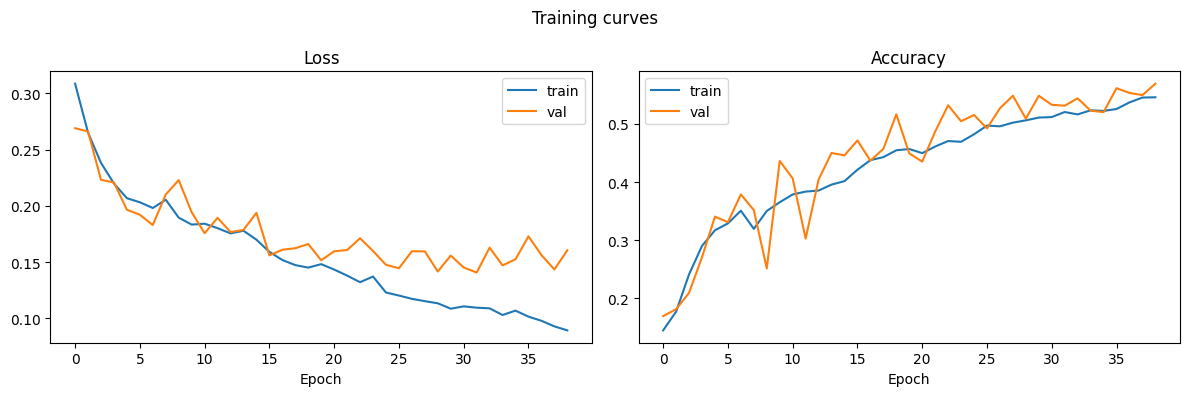

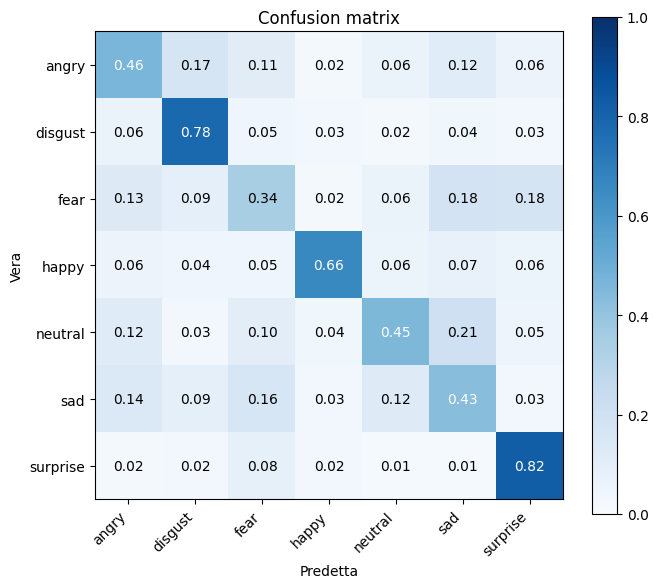

              precision    recall  f1-score   support

       angry      0.433     0.462     0.447       946
     disgust      0.146     0.780     0.245       109
        fear      0.371     0.341     0.355      1013
       happy      0.892     0.658     0.757      1767
     neutral      0.583     0.455     0.511      1225
         sad      0.433     0.427     0.430      1240
    surprise      0.599     0.821     0.692       792

    accuracy                          0.531      7092
   macro avg      0.494     0.563     0.491      7092
weighted avg      0.578     0.531     0.544      7092

Macro F1 (media semplice tra classi, penalizza le classi piccole se vanno male): 0.491
Weighted F1 (pesata per frequenza di classe): 0.544


In [4]:
from src.evaluate import evaluate_model

class_names = sorted(label2idx, key=label2idx.get)  # ordine coerente con gli indici usati nel training

y_true, y_pred = evaluate_model(model, test_loader, class_names, history=history)

### Proviamo con solo Focal Loss e non Class Weights


In [5]:
model = DeepCNN(num_classes=7)
model, history = train_model(
    model, train_loader, val_loader,
    num_classes=7, y_train=data['y_train'],
    use_class_weights=False,
    loss_type='focal', focal_gamma=2.0,  
    epochs=50, patience=7,
    checkpoint_path='../results/deep_cnn_focal2.pt'   
)

/home/stetux/projects/NAML/FacialExpressionRecognition/notebooks/../src/train.py:144: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler() if device.type == 'cuda' else None


Epoch   1/50 | train_loss=1.1176 train_acc=0.3664 | val_loss=0.8522 val_acc=0.4853 | lr=1.00e-03 | 104.0s
Epoch   2/50 | train_loss=0.8596 train_acc=0.4809 | val_loss=0.7862 val_acc=0.5002 | lr=1.00e-03 | 103.7s
Epoch   3/50 | train_loss=0.8002 train_acc=0.5074 | val_loss=1.2607 val_acc=0.4286 | lr=1.00e-03 | 103.9s
Epoch   4/50 | train_loss=0.7791 train_acc=0.5237 | val_loss=0.7153 val_acc=0.5544 | lr=1.00e-03 | 103.6s
Epoch   5/50 | train_loss=0.7347 train_acc=0.5436 | val_loss=0.6786 val_acc=0.5788 | lr=1.00e-03 | 103.4s
Epoch   6/50 | train_loss=0.7142 train_acc=0.5491 | val_loss=0.6653 val_acc=0.5829 | lr=1.00e-03 | 103.4s
Epoch   7/50 | train_loss=0.6915 train_acc=0.5657 | val_loss=0.7539 val_acc=0.5284 | lr=1.00e-03 | 103.6s
Epoch   8/50 | train_loss=0.6767 train_acc=0.5682 | val_loss=0.7221 val_acc=0.5299 | lr=1.00e-03 | 103.4s
Epoch   9/50 | train_loss=0.6517 train_acc=0.5838 | val_loss=0.6275 val_acc=0.5941 | lr=1.00e-03 | 103.9s
Epoch  10/50 | train_loss=0.6512 train_acc=0.5

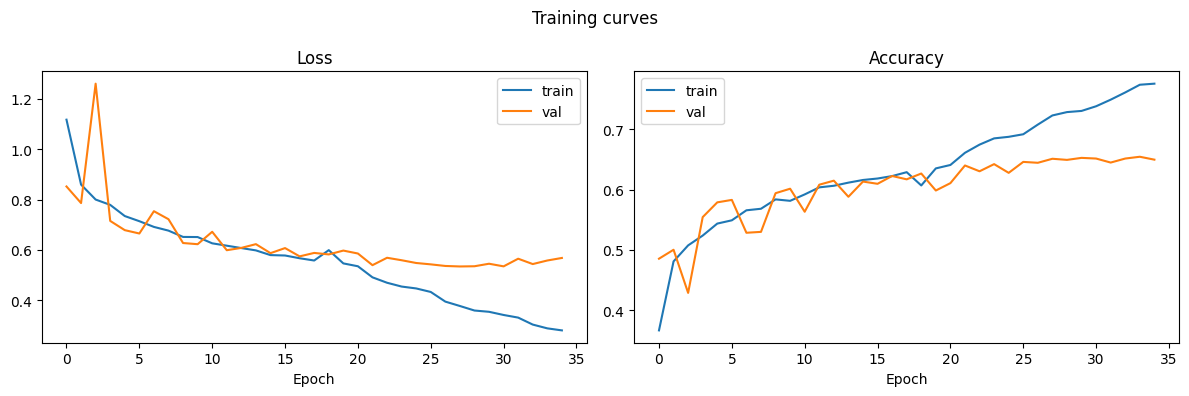

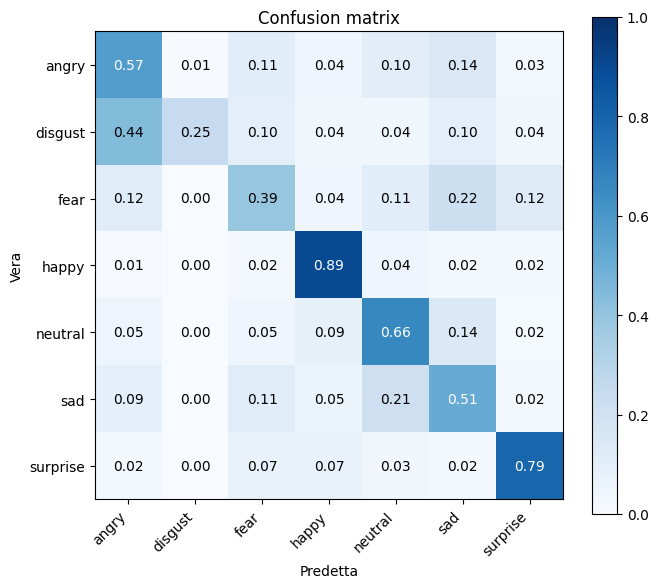

              precision    recall  f1-score   support

       angry      0.592     0.574     0.583       946
     disgust      0.659     0.248     0.360       109
        fear      0.502     0.394     0.441      1013
       happy      0.839     0.895     0.866      1767
     neutral      0.585     0.661     0.621      1225
         sad      0.520     0.508     0.514      1240
    surprise      0.731     0.793     0.761       792

    accuracy                          0.651      7092
   macro avg      0.633     0.582     0.592      7092
weighted avg      0.643     0.651     0.644      7092

Macro F1 (media semplice tra classi, penalizza le classi piccole se vanno male): 0.592
Weighted F1 (pesata per frequenza di classe): 0.644


In [6]:
from src.evaluate import evaluate_model

class_names = sorted(label2idx, key=label2idx.get)  # ordine coerente con gli indici usati nel training

y_true, y_pred = evaluate_model(model, test_loader, class_names, history=history)